# Creusement d'un tunnel au tunnelier · 1. Exploration des données

Projet de recherche de 1re année, École des Ponts, février-mars 2026.

Les données décrivent le creusement au tunnelier d'un tronçon de tunnel de métro en région parisienne : la géométrie de chaque anneau de voussoirs, la stratigraphie traversée, les paramètres mécaniques des sols, les paramètres de pilotage du tunnelier et le tassement mesuré en surface.

> **Données synthétiques.** Les données réelles du projet sont confidentielles. Ce notebook tourne sur un jeu synthétique de même structure, créé par `scripts/make_synthetic_data.py`. Les chiffres et les figures ci-dessous montrent la démarche, pas les résultats du vrai tunnel.

Ce notebook décrit les données. Le second, `02_modelisation.ipynb`, prédit le tassement.

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# données synthétiques par défaut ; TUNNEL_DATA=chemin pour les vraies données (équipe seulement)
DATA = Path(os.environ.get("TUNNEL_DATA", "../data/synthetic"))

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

## 1. Les tables

Chaque anneau posé par le tunnelier porte un identifiant `id_anneau`, qui sert de clé de jointure entre toutes les tables.

In [2]:
anneau = pd.read_csv(DATA / "anneau.csv")
strati = pd.read_csv(DATA / "stratigraphie.csv")
formations = pd.read_csv(DATA / "formation_geologique.csv")
secteurs = pd.read_csv(DATA / "secteur.csv")
tunnelier = pd.read_csv(DATA / "parametre_tunnelier.csv")
sol = pd.read_csv(DATA / "stratigraphie_homogenisee.csv")
smax = pd.read_csv(DATA / "smax.csv")

tables = {
    "anneau": (anneau, "géométrie de chaque anneau : PK, altitudes du terrain et du tunnel"),
    "stratigraphie": (strati, "couches géologiques au droit de chaque anneau"),
    "formation_geologique": (formations, "nom et couleur de chaque formation"),
    "secteur": (secteurs, "découpage du tracé en secteurs homogènes"),
    "parametre_tunnelier": (tunnelier, "paramètres de pilotage enregistrés pour chaque anneau"),
    "stratigraphie_homogenisee": (sol, "paramètres de sol équivalents par anneau"),
    "smax": (smax, "tassement maximal mesuré en surface, par section instrumentée"),
}
pd.DataFrame(
    [(nom, len(t), t.shape[1], role) for nom, (t, role) in tables.items()],
    columns=["table", "lignes", "colonnes", "contenu"],
).set_index("table")

,lignes,colonnes,contenu
table,,,
anneau,4000,6,"géométrie de chaque anneau : PK, altitudes du ..."
stratigraphie,27132,6,couches géologiques au droit de chaque anneau
formation_geologique,7,6,nom et couleur de chaque formation
secteur,6,7,découpage du tracé en secteurs homogènes
parametre_tunnelier,4000,13,paramètres de pilotage enregistrés pour chaque...
stratigraphie_homogenisee,4000,8,paramètres de sol équivalents par anneau
smax,424,5,"tassement maximal mesuré en surface, par secti..."


## 2. Profil en long

La **couverture** est l'épaisseur de terrain au-dessus de la voûte du tunnel : $C = z_{TN} - z_{voûte}$. Le profil ci-dessous montre les formations traversées le long du tracé, avec la couleur de chaque formation.

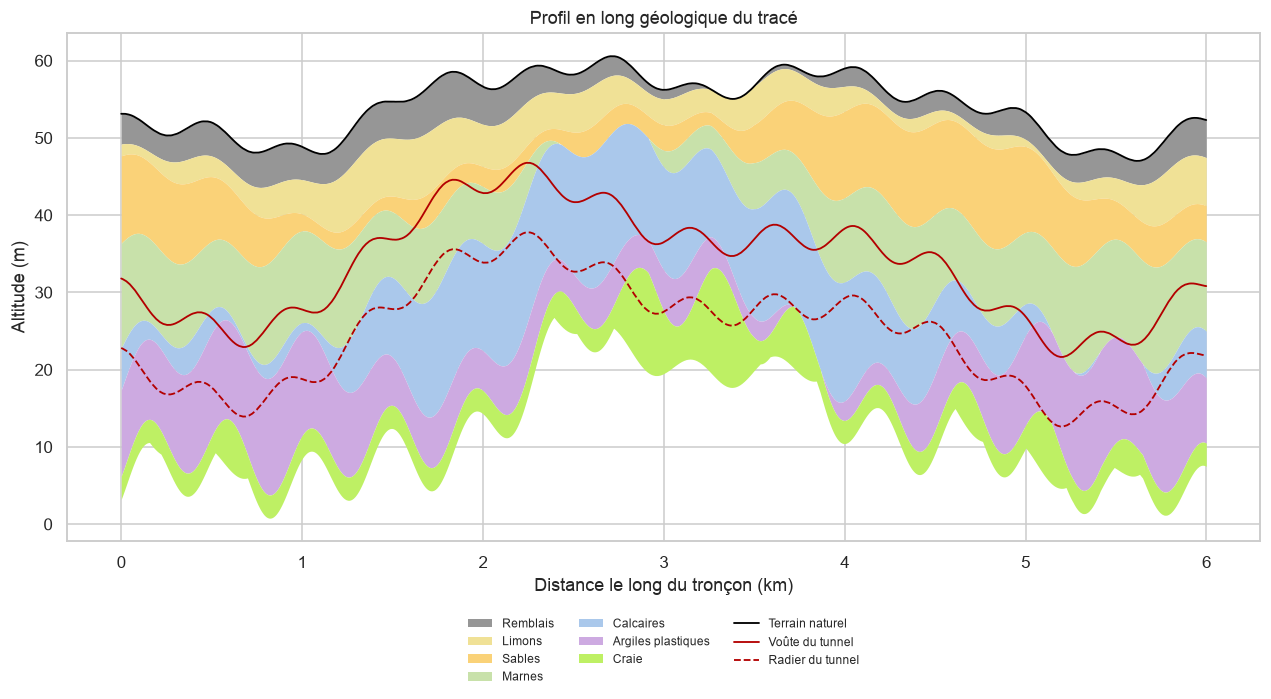

min    11.9
50%    21.0
max    27.3
Name: couverture (m), dtype: float64

In [3]:
anneau = anneau.sort_values("pk")
anneau["couverture"] = anneau["z_tn"] - anneau["z_voute_tunnel"]
# distance depuis le début du tronçon, plus lisible que le PK brut
anneau["km"] = (anneau["pk"] - anneau["pk"].min()) / 1000

couches = (
    strati.merge(anneau[["id_anneau", "km"]], on="id_anneau")
    .merge(formations[["id_formation", "nom", "ordre", "couleur_r", "couleur_v", "couleur_b"]],
           on="id_formation", how="left")
    .sort_values(["ordre", "km"])
)

fig, ax = plt.subplots(figsize=(14, 6))
for (code_formation, nom), couche in couches.groupby(["id_formation", "nom"], sort=False):
    rgb = couche[["couleur_r", "couleur_v", "couleur_b"]].iloc[0].to_numpy(dtype=float) / 255
    couleur = rgb if np.isfinite(rgb).all() else (0.75, 0.75, 0.75)
    # une bande par portion continue de la couche le long du tracé
    morceaux = (couche["km"].diff() > 0.02).cumsum()
    for i, (_, morceau) in enumerate(couche.groupby(morceaux)):
        ax.fill_between(morceau["km"], morceau["z_base"], morceau["z_toit"], color=couleur,
                        lw=0, label=nom if i == 0 else None)

ax.plot(anneau["km"], anneau["z_tn"], color="black", lw=1.2, label="Terrain naturel")
ax.plot(anneau["km"], anneau["z_voute_tunnel"], color="#b30000", lw=1.2, label="Voûte du tunnel")
ax.plot(anneau["km"], anneau["z_base_tunnel"], color="#b30000", lw=1.2, ls="--", label="Radier du tunnel")
ax.set(xlabel="Distance le long du tronçon (km)", ylabel="Altitude (m)", title="Profil en long géologique du tracé")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.13), ncol=3, fontsize=8, frameon=False)
plt.show()

anneau["couverture"].describe()[["min", "50%", "max"]].round(1).rename("couverture (m)")

## 3. Le tunnelier

Six paramètres de pilotage sont retenus pour la suite. La pression d'injection du mortier est la moyenne des quatre capteurs A1, A2, A5 et A6.

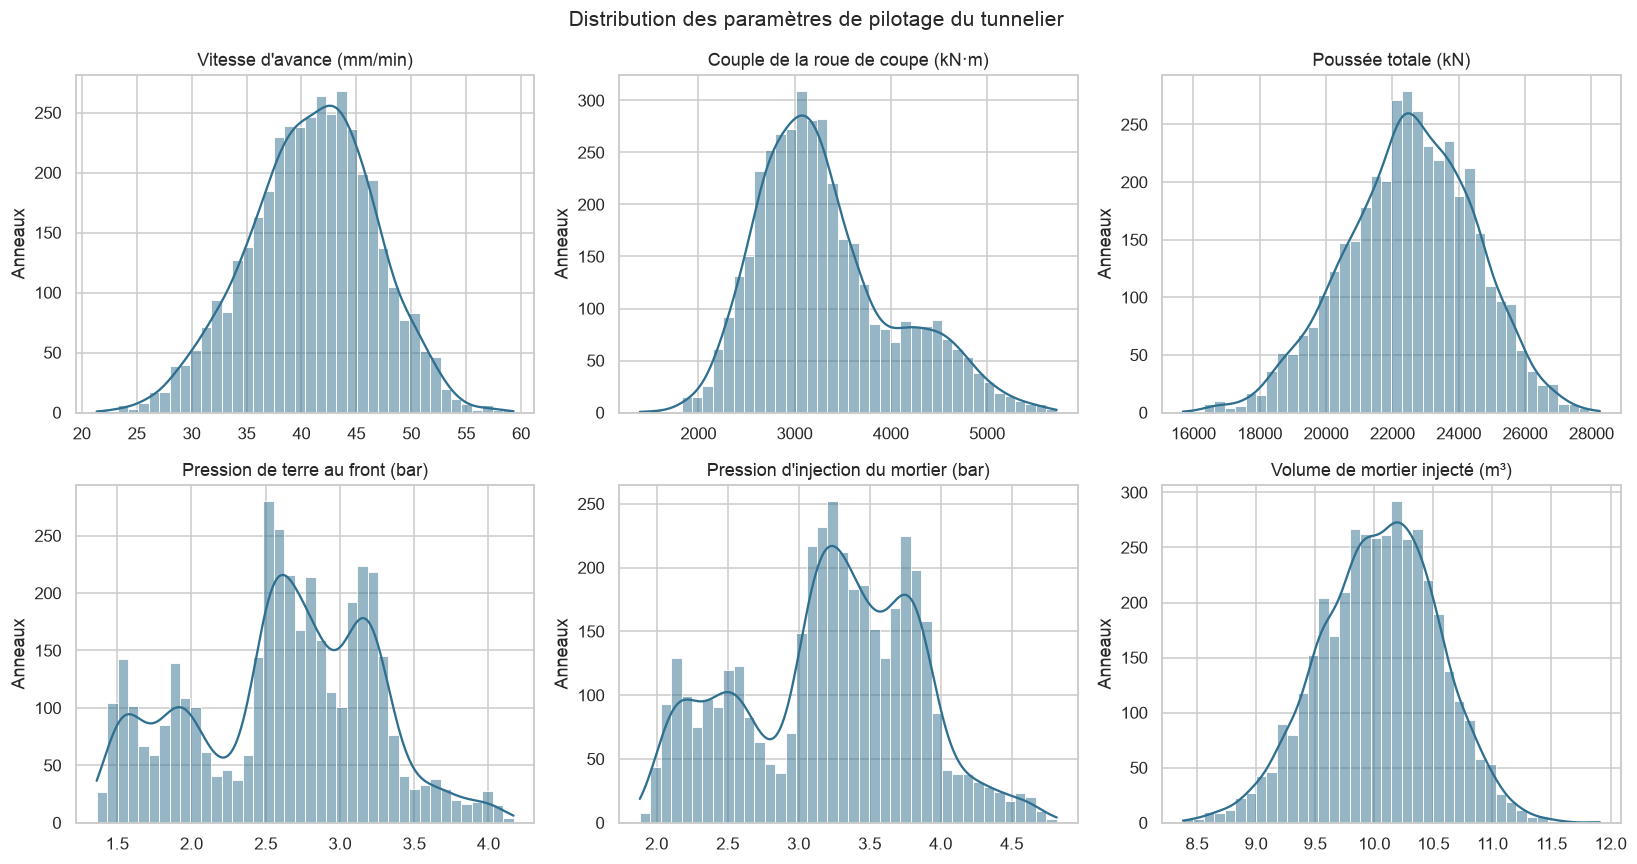

,min,mean,max
Vitesse d'avance (mm/min),21.36,40.93,59.31
Couple de la roue de coupe (kN·m),1392.11,3316.58,5723.50
Poussée totale (kN),15686.59,22522.63,28253.32
Pression de terre au front (bar),1.36,2.62,4.17
Pression d'injection du mortier (bar),1.88,3.22,4.82
Volume de mortier injecté (m³),8.38,10.04,11.91


In [4]:
tunnelier["PressionInjectionMortier[bar]"] = tunnelier[
    [f"PressionInjectionMortier{a}[bar]" for a in ("A1", "A2", "A5", "A6")]
].mean(axis=1)

PARAMETRES_TUNNELIER = {
    "Avance_RDC[mm/mn]": "Vitesse d'avance (mm/min)",
    "Couple_RDC[kN.m]": "Couple de la roue de coupe (kN·m)",
    "PousseeTotale[kN]": "Poussée totale (kN)",
    "CapteurPressionsTerreFront1[bar]": "Pression de terre au front (bar)",
    "PressionInjectionMortier[bar]": "Pression d'injection du mortier (bar)",
    "QuantiteMortierInjecteTotale[m3]": "Volume de mortier injecté (m³)",
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (colonne, titre) in zip(axes.flat, PARAMETRES_TUNNELIER.items()):
    sns.histplot(tunnelier[colonne].dropna(), bins=40, kde=True, ax=ax, color="#2f6f8f")
    ax.set(title=titre, xlabel="", ylabel="Anneaux")
fig.suptitle("Distribution des paramètres de pilotage du tunnelier", fontsize=14)
fig.tight_layout()
plt.show()

(tunnelier[list(PARAMETRES_TUNNELIER)].describe().T[["min", "mean", "max"]]
 .rename(index=PARAMETRES_TUNNELIER).round(2))

## 4. Les sols

La stratigraphie compte jusqu'à sept couches par anneau. Pour obtenir une valeur par anneau, le cours fournit une table homogénéisée : chaque paramètre $x$ y est combiné sur les $n$ couches selon

$$x_{eq} = \sum_{i=1}^{n} \frac{e_i}{C} \cdot \frac{h_i}{C} \cdot x_i$$

où $e_i$ est l'épaisseur de la couche $i$, $h_i$ sa profondeur et $C$ la couverture (formule adaptée de Chen et al., 2019). Le paramètre combiné perd son sens physique, mais il résume en un nombre la mécanique du terrain au-dessus du tunnel.

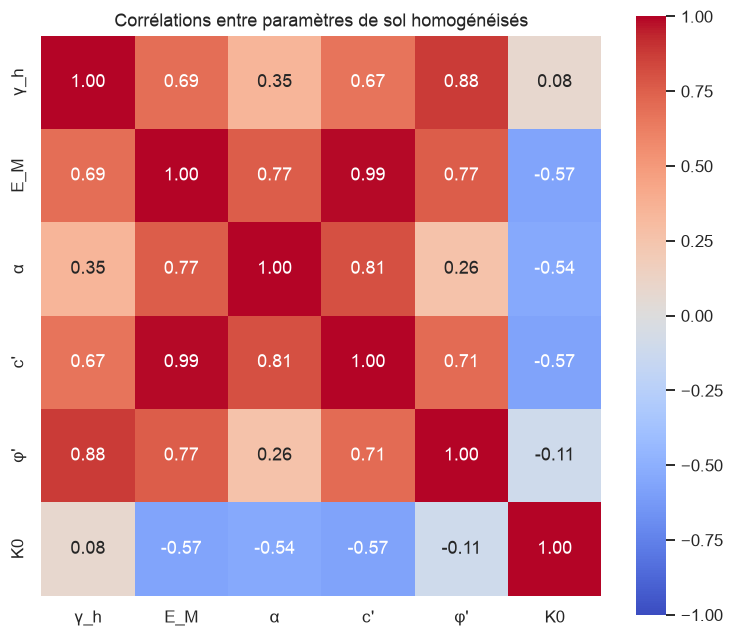

In [5]:
PARAMETRES_SOL = {
    "gamma_h[kN/m3]": "γ_h",
    "E_M[MPa]": "E_M",
    "alpha[]": "α",
    "c'[kPa]": "c'",
    "phi'[°]": "φ'",
    "K0[]": "K0",
}
corr_sol = sol[list(PARAMETRES_SOL)].rename(columns=PARAMETRES_SOL).corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_sol, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title("Corrélations entre paramètres de sol homogénéisés")
fig.tight_layout()
plt.show()

## 5. Le tassement en surface

La variable à prédire est `smax`, le tassement maximal (en mm) de la cuvette de tassement ajustée sur chaque section de mesure transversale. Il est négatif : le sol descend.

Le tassement n'est mesuré que dans quelques zones instrumentées, et il varie peu d'un anneau à son voisin. Il faudra s'en souvenir au moment d'évaluer les modèles.

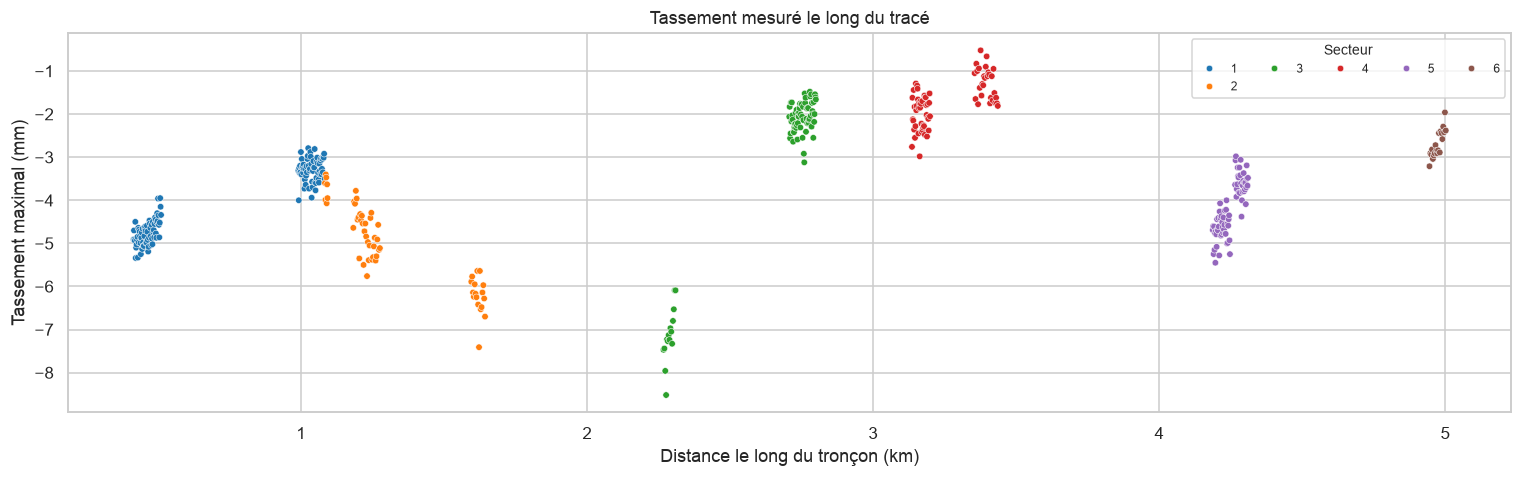

count    424.00
mean      -3.57
std        1.51
min       -8.52
25%       -4.69
50%       -3.47
75%       -2.26
max       -0.52
Name: tassement maximal (mm), dtype: float64

In [6]:
tassement = smax.merge(anneau[["id_anneau", "km", "id_secteur"]], on="id_anneau")

fig, ax = plt.subplots(figsize=(14, 4.5))
sns.scatterplot(data=tassement, x="km", y="smax", hue="id_secteur", palette="tab10", s=18, ax=ax)
ax.set(xlabel="Distance le long du tronçon (km)", ylabel="Tassement maximal (mm)",
       title="Tassement mesuré le long du tracé")
ax.legend(title="Secteur", ncol=5, fontsize=8, title_fontsize=9)
fig.tight_layout()
plt.show()

smax["smax"].describe().round(2).rename("tassement maximal (mm)")